# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

En el dataset **users**, las columnas que presentan valores nulos son:

`churn_date`: 3,534 valores nulos (88.35%).
`city`: 469 valores nulos (11.7%).

En el dataset **usage**, las columnas que presentan valores nulos son:

`duration`: 22,076 valores nulos (55.19%).
`length`: 17,896 valores nulos (44.74%).
`date`: 50 valores nulos (0.12%).
  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Para las columnas *churn_date, duration y length*, se recomienda mantener los valores nulos sin imputarlos, ya que representan información asociada a eventos específicos.

- `churn_date`: los valores nulos pueden indicar que el usuario no ha abandonado el servicio. Imputarlos podría alterar la interpretación del abandono.
- `duration`: los valores nulos están relacionados con la duración de las llamadas y no deberían reemplazarse automáticamente, ya que podrían representar registros sin información de duración.
- `length`: los valores nulos corresponden a la longitud de los mensajes y, al igual que duration, se recomienda mantenerlos como nulos para evitar introducir valores artificiales.

En el caso de city, también se recomienda mantener los valores nulos, ya que imputar una ciudad podría introducir información que no está presente en los datos originales.

Finalmente, para la columna date del dataset **usage**, debido a que la proporción de valores nulos es muy baja (0.12%), sería conveniente revisar esos registros antes de decidir si eliminarlos, especialmente si la fecha es necesaria para realizar análisis temporales. Si esos registros no son relevantes para el análisis, podrían eliminarse.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:

num_cols_rs = ["user_id", "age"]
users[num_cols_rs].describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... contien **4,000 identificadores unicos**, cuyos valores van desde **10,000 hasta 13,999.**
- La columna `age` ... contiene las edades de los usuarios, con un valor mínimo de **-999**, que corresponde a un **valor sentinel** utilizado para representar datos faltantes o no válidos. La mediana es de **47 años**, mientras que el promedio es de **33.7 años**. Esta diferencia puede estar afectada por la presencia de los valores sentinel, por lo que las estadísticas deben recalcularse después de tratarlos. La desviación estándar es de **123 años**, un valor considerablemente alto para una variable como la edad, lo que confirma que existen valores atípicos o inconsistencias en los datos. El valor máximo registrado es de **79 años**.


In [13]:
num_cols_ge = ["id", "user_id", "duration", "length"]
usage[num_cols_ge].describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`... La columna `user_id` parece presentar una relación con el campo `user_id` del dataset **users**, por lo que podría utilizarse como identificador común para relacionar ambas tablas. En cuanto a la columna id, se identifican 40,000 movimientos y no se observan inconsistencias evidentes en sus valores.
- Las columnas ... `duration` y `length` representan 2 diferentes eventos que en conjunto permiten identificar los 40,000 movimientos registrados: duration corresponde a la duración de las llamadas, mientras que length representa la longitud de los mensajes de texto.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` ... contiene 3,531 registros con información, distribuidos entre 7 ciudades. La ciudad con mayor frecuencia es Bogotá, con 808 registros, siendo la ciudad más representada en el dataset.
- La columna `plan` ... contiene información para los 4,000 usuarios y presenta 2 planes diferentes. De estos registros, 2,595 corresponden al plan Básico, por lo que este es el plan con mayor representación en el dataset.

In [15]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` ... contiene 2 valores únicos. El valor text es el más frecuente, con 22,092 registros, por lo que representa la mayor proporción de los eventos registrados en esta columna.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

    La columana `age` contiene sentinels y la columna `city` valores invalidos o nulos.

- ¿Qué acción tomarías?

  Para la columna `age` recomiendo imputar con la mediana, y en la columan `city` mantendria los valores nulos para no alterar los registros.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:

# Revisar los años presentes en `reg_date` de users
users["año"] = users["reg_date"].dt.year
users["año"].value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: año, dtype: int64

En `reg_date`, ... Existen 40 valores invalidos invalidos.

In [19]:
# Revisar los años presentes en `date` de usage
usage["año"] = usage["date"].dt.year
usage["año"].value_counts()

2024.0    39950
Name: año, dtype: int64

En `date`, ... Existen 50 valores nulos.  
Basaremos el análisis en estas fechas.



✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
En el dataset **users**, aparecen 40 años imposibles, que representan el 1% de los registros.
En el dataset **usage**, aparecen 50 valores nulls, que representan el 1.25% de los registros
  
- ¿Qué harías con ellas?
Revisar las fechas imposibles, si no es posible determinar la fecha correctar manejarlos como Nulls.
Y asi, determinar si estos registros faltantes podrian afectar el analisis, o podemos eliminarlos. 


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, pd.NA)
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date']= users['reg_date'].dt.year.replace(2026, pd. NA)

# Verificar cambios
users['reg_date'].value_counts()

2024    1330
2023    1316
2022    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

- Podemos observar como no exiten valores nulos en `duration` para registros tipo *call*  y no existen valores nulos en `length` para registros tipo *text*. Con lo que se demuestra que dependen del tipo de registro (`type`).


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas", "duration" : "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,2022,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,2022,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,2022,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,2022,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,2022,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas

num_cols = ["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

user_profile[num_cols].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan

print("Frecuencia absoluta:")
print(user_profile["plan"].value_counts())

print("\nFrecuencia relativa:")
print(user_profile["plan"].value_counts(normalize=True))

Frecuencia absoluta:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Frecuencia relativa:
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

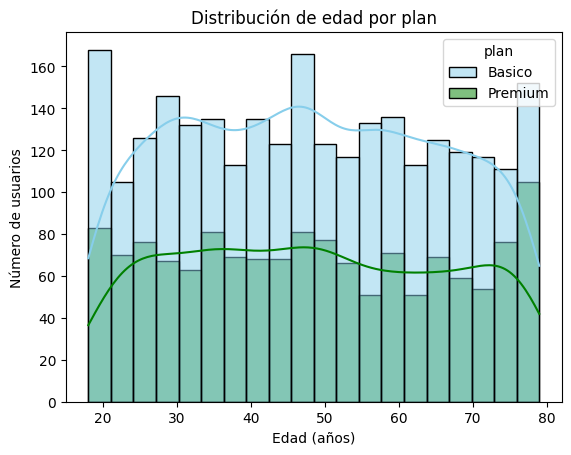

In [30]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x="age", bins=20, hue="plan",  kde=True, palette=['skyblue','green'])

plt.title("Distribución de edad por plan")
plt.xlabel("Edad (años)")
plt.ylabel("Número de usuarios")
plt.show()


💡Insights: 
- Distribución es uniforme para ambos planes.
- En los usuarios Básico destaca un pico en usuarios jovenes y de mediana edad, mientras que en los usuarios Premium destacan ligeramente los de edad avanzada.
- ¿Qué tipo de distribución tiene? **Simétrica**


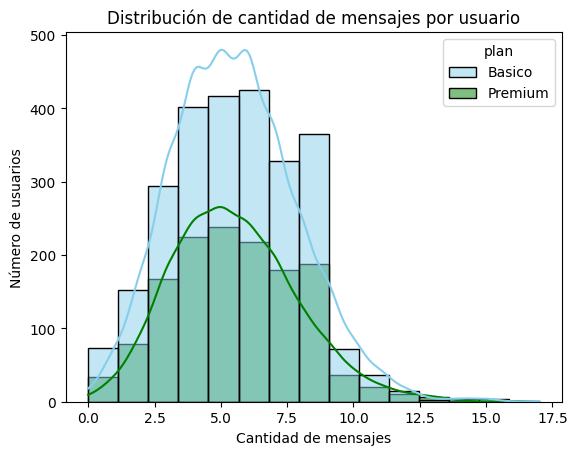

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x="cant_mensajes", bins=15, hue="plan",  kde=True, palette=['skyblue','green'])

plt.title("Distribución de cantidad de mensajes por usuario")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Número de usuarios")
plt.show()


💡Insights: 
- Se observa sesgo hacia la derecha para ambos planes, lo que nos indica posibles outliers.
- ¿Qué tipo de distribución tiene ? **Sesgada a la derecha**


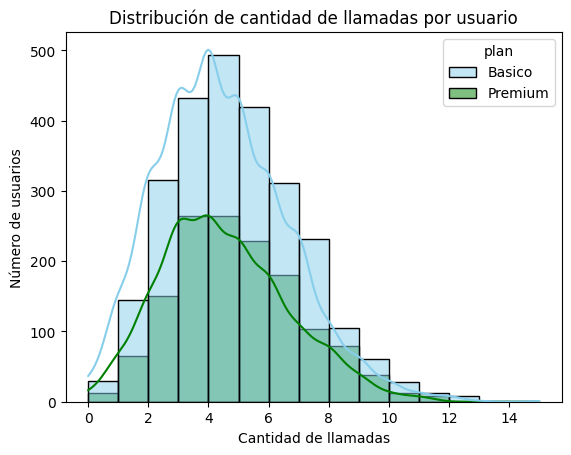

In [32]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", bins=15, hue="plan",  kde=True, palette=['skyblue','green'])

plt.title("Distribución de cantidad de llamadas por usuario")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Número de usuarios")
plt.show()



💡Insights: 
- "En ambos planes se muestra sesgo a la derecha" 
- ¿Qué tipo de distribución tiene ? **sesgada a la derecha**

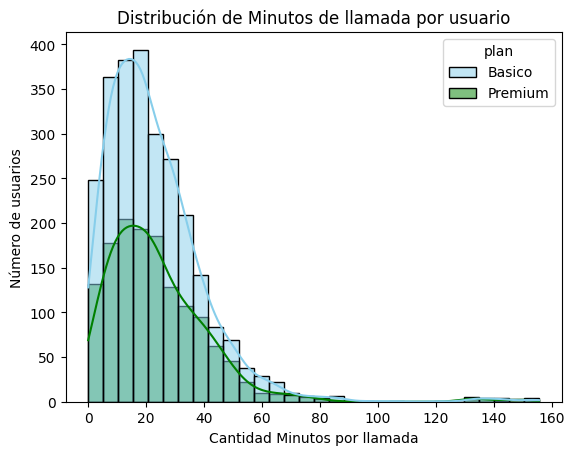

In [33]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x="cant_minutos_llamada", bins=30, hue="plan",  kde=True, palette=['skyblue','green'])

plt.title("Distribución de Minutos de llamada por usuario")
plt.xlabel("Cantidad Minutos por llamada")
plt.ylabel("Número de usuarios")
plt.show()

💡Insights: 
- En ambos planes se muestra una distribucion sesgada a la derecha.
- En usuarios basicos destacan llamas de menos de 30min, con el 75%.
- ¿Qué tipo de distribución tiene ? **sesgada a la derecha**

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

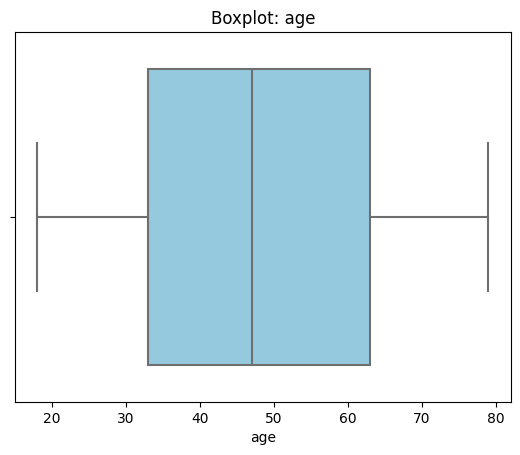

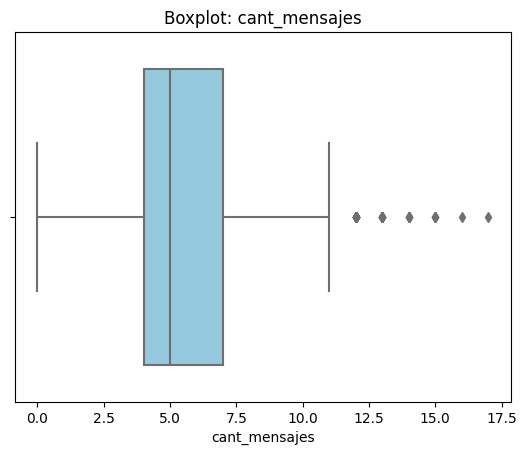

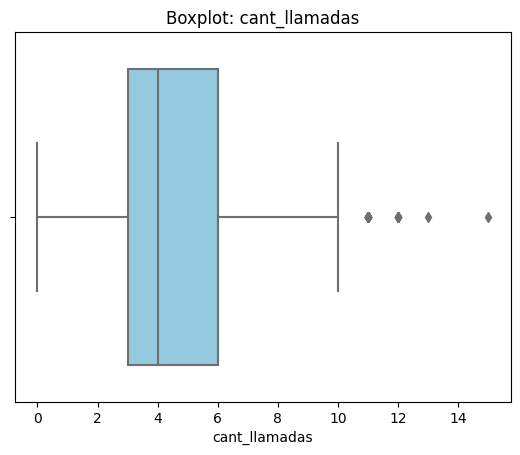

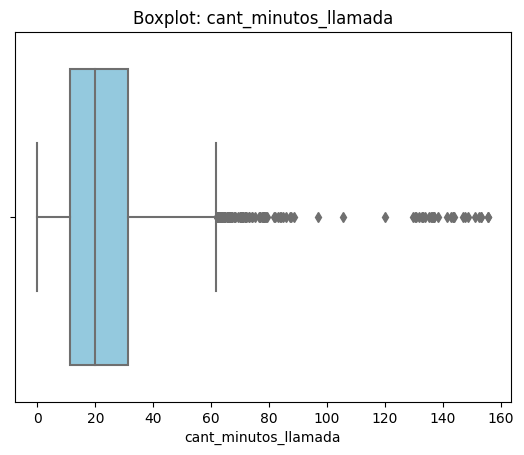

In [34]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title((f'Boxplot: {col}'))
    plt.xlabel(f'{col}')
    plt.show()


💡Insights: 
- Age: no presenta outliers
- cant_mensajes: Si presenta outliers
- cant_llamadas: Si presenta outliers
- cant_minutos_llamada: Si presenta outliers

In [35]:


# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for coll in columnas_limites:
    Q1 = user_profile[coll].quantile(0.25)
    Q3 = user_profile[coll].quantile(0.75)
    IQR = Q3 - Q1

    print(coll , "IQR: ", IQR)

    upper= Q3 + 1.5*IQR
    lower= Q1 - 1.5*IQR
    
    print("Límite inferior:", lower)
    print("Límite superior:", upper)

    outliers = user_profile[
    (user_profile[coll] > upper) |
    (user_profile[coll] < lower)
]
    print(coll, "→", len(outliers), "outliers")
    
    display(user_profile[
    (user_profile[coll] > upper) |
    (user_profile[coll] < lower) ])

    


cant_mensajes IQR:  3.0
Límite inferior: -0.5
Límite superior: 11.5
cant_mensajes → 46 outliers


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada
315,10315,Carlos,Lopez,30.0,MTY,2022,Basico,NaN,2022,13.0,3.0,12.36
347,10347,Carlos,Garcia,77.0,Cali,2022,Basico,NaN,2022,13.0,3.0,21.40
356,10356,Mateo,Garcia,42.0,CDMX,2022,Basico,NaN,2022,12.0,5.0,59.48
384,10384,Sofia,Ramirez,35.0,CDMX,2022,Premium,NaN,2022,12.0,3.0,13.05
456,10456,Mateo,Ramirez,47.0,CDMX,2022,Basico,"1,72653E+18",2022,12.0,1.0,2.24
539,10539,Sofia,Ramirez,77.0,Cali,2022,Basico,NaN,2022,14.0,5.0,8.66
591,10591,Ana,Gomez,25.0,NaN,2022,Basico,NaN,2022,12.0,2.0,16.52
670,10670,Carlos,Torres,47.0,Bogotá,2022,Basico,NaN,2022,12.0,3.0,19.13
903,10903,Carlos,Lopez,63.0,CDMX,2022,Premium,"1,72938E+18",2022,12.0,3.0,8.89
908,10908,Mariana,Lopez,56.0,MTY,2022,Basico,NaN,2022,14.0,3.0,12.50


cant_llamadas IQR:  3.0
Límite inferior: -1.5
Límite superior: 10.5
cant_llamadas → 30 outliers


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada
116,10116,Ana,Garcia,52.0,CDMX,2022,Basico,NaN,2022,3.0,11.0,44.32
417,10417,Luis,Garcia,70.0,Bogotá,2022,Basico,NaN,2022,4.0,12.0,26.42
777,10777,Sofia,Lopez,65.0,Cali,2022,Basico,NaN,2022,4.0,12.0,55.28
778,10778,Mateo,Lopez,77.0,NaN,2022,Basico,NaN,2022,8.0,11.0,32.13
862,10862,Luis,Ramirez,23.0,Bogotá,2022,Basico,NaN,2022,4.0,15.0,78.11
1013,11013,Mateo,Lopez,65.0,CDMX,2022,Basico,NaN,2022,4.0,11.0,60.83
1564,11564,Carlos,Lopez,41.0,CDMX,2023,Basico,NaN,2023,8.0,11.0,30.17
1614,11614,Mateo,Garcia,73.0,Bogotá,2023,Basico,NaN,2023,5.0,11.0,41.80
1912,11912,Mariana,Garcia,48.0,Medellín,2023,Premium,NaN,2023,2.0,11.0,65.71
2013,12013,Mateo,Lopez,48.0,GDL,2023,Basico,NaN,2023,2.0,12.0,65.55


cant_minutos_llamada IQR:  20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575
cant_minutos_llamada → 109 outliers


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada
27,10027,Ana,Gomez,28.0,MTY,2022,Premium,NaN,2022,8.0,7.0,84.77
85,10085,Carlos,Ramirez,65.0,GDL,2022,Basico,NaN,2022,6.0,5.0,152.36
93,10093,Ana,Torres,67.0,Medellín,2022,Basico,NaN,2022,2.0,7.0,71.57
189,10189,Mariana,Torres,63.0,MTY,2022,Basico,NaN,2022,9.0,4.0,155.42
198,10198,Sofia,Gomez,58.0,Medellín,2022,Basico,"1,73033E+18",2022,8.0,9.0,78.77
...,...,...,...,...,...,...,...,...,...,...,...,...
3920,13920,Mariana,Lopez,48.0,Bogotá,2024,Premium,NaN,2024,4.0,5.0,132.72
3927,13927,Mariana,Lopez,18.0,GDL,2024,Basico,"1,72549E+18",2024,8.0,4.0,135.96
3945,13945,Luis,Ramirez,30.0,Bogotá,2024,Basico,NaN,2024,7.0,3.0,133.97
3953,13953,Mateo,Gomez,58.0,GDL,2024,Basico,NaN,2024,0.0,7.0,155.69


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Mantener outliers, porqué?, podrian ser usuarios que usan con mayor frecuencia esta modalidad
- cant_llamadas: Mantener outliers, porqué?, podrian ser usuarios que usan con mayor frecuencia esta modalidad
- cant_minutos_llamada: Mantener outliers, porqué?, podrian ser usuarios que usan con mayor frecuencia esta modalidad

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso

user_profile["grupo_uso"] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] <5), "Bajo uso", 
        np.where((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), "Uso medio", "Alto uso"))


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,2022,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,2022,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,2022,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,2022,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where(
    (user_profile['age'] < 30), "Joven", 
        np.where((user_profile['age'] < 60), "Adulto", "Adulto Mayor"))


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,año,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022,Basico,NaN,2022,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022,Basico,NaN,2022,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022,Basico,NaN,2022,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022,Premium,NaN,2022,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022,Basico,NaN,2022,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

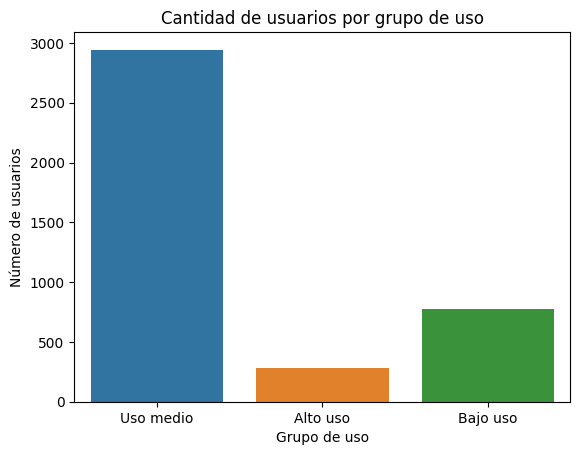

In [41]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x="grupo_uso"
)

plt.title("Cantidad de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Número de usuarios")
plt.show()

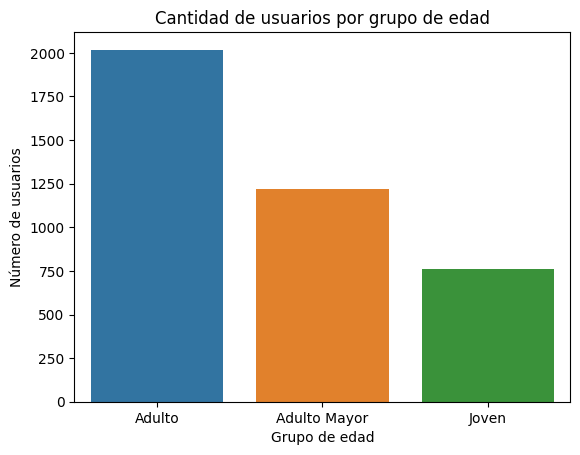

In [42]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad"
)

plt.title("Cantidad de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de usuarios")
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 

- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

En el dataset users, se identificaron los siguientes problemas de calidad de datos:

- churn_date: presenta 3,534 valores nulos (88.35%).
- city: presenta 469 valores nulos (11.7%).
- age: contiene un valor mínimo de -999, el cual corresponde a un valor sentinel y no representa una edad válida.


🔍 **Segmentos por Edad**

Se identificaron tres segmentos de clientes según su edad:

- Adultos (30 a 59 años): aproximadamente 2,000 usuarios, siendo el segmento más numeroso.
- Mayores de 60 años: aproximadamente 1,250 usuarios.
- Jóvenes (menores de 30 años): aproximadamente 750 usuarios, siendo el segmento menos numeroso.

📊 **Segmentos por Nivel de Uso**

Según el nivel de uso, se identificaron tres segmentos:

- Uso medio: más de 2,500 usuarios, siendo el segmento predominante.
- Uso bajo: cerca de 1,000 usuarios.
- Uso alto: aproximadamente 250 usuarios, siendo el segmento menos numeroso.


➡️ Esto sugiere que ...

Los usuarios de nivel de uso medio podrían representar uno de los segmentos más valiosos para ConnectaTel, ya que existe una oportunidad de implementar estrategias que incentiven un mayor uso del servicio y permitan convertir parte de estos usuarios en clientes de uso alto.

Por otro lado, el segmento de adultos de 30 a 59 años, al ser el grupo con mayor presencia en la base de usuarios, también representa una oportunidad importante. Se podrían desarrollar planes y estrategias comerciales específicamente dirigidos a este grupo etario, considerando sus necesidades y patrones de consumo.

Además, sería recomendable realizar una investigación específica de los valores atípicos (outliers) para identificar si corresponden a usuarios con un comportamiento de uso excepcionalmente alto. Analizar características como edad, datos demográficos, nivel de uso y fecha de registro podría ayudar a comprender qué factores están relacionados con estos comportamientos y determinar si representan clientes de alto valor para ConnectaTel.

💡 **Recomendaciones**

Se recomienda implementar las siguientes acciones:

- Enfocar la oferta en usuarios adultos (30 a 59 años): al representar el segmento de mayor presencia, se podrían diseñar planes y promociones adaptados a sus necesidades y patrones de consumo.
- Impulsar a los usuarios de uso medio: crear incentivos, beneficios o planes escalonados que motiven a estos usuarios a incrementar su consumo y evolucionar hacia el segmento de uso alto.
- Investigar los outliers: analizar a los usuarios con comportamientos de uso atípicos para determinar si representan clientes de alto valor. Esto permitiría identificar características y patrones que podrían utilizarse para diseñar ofertas específicas o estrategias de fidelización.

En conjunto, estas estrategias permitirían segmentar mejor la oferta, aumentar el nivel de uso de los clientes y detectar oportunidades de crecimiento y fidelización.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`